<a href="https://colab.research.google.com/github/quasar-in-the-mist/Numerical-Relativity/blob/main/Bootstrap_Structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

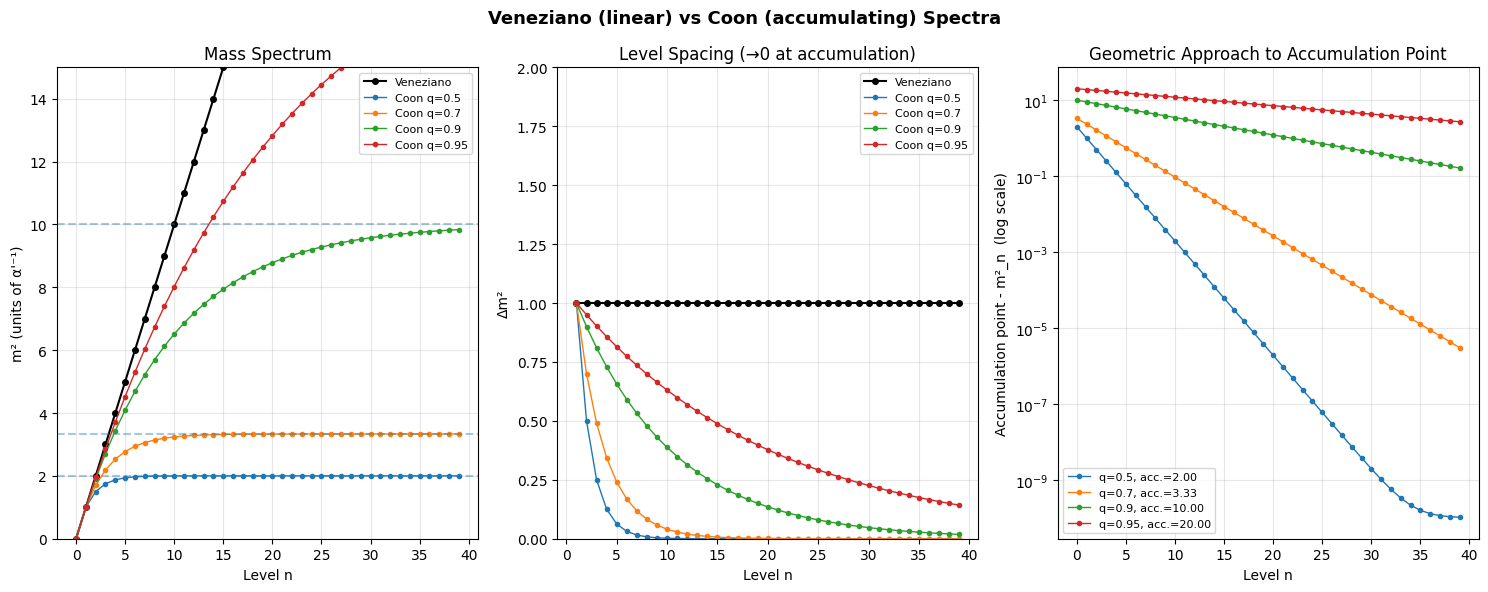

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ──────────────────────────────────────────────
q_values = [0.5, 0.7, 0.9, 0.95]
n_levels = 40
n = np.arange(0, n_levels)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# ── Plot 1: Mass Spectrum (m² vs level) ─────────────────────
ax1 = axes[0]

# Veneziano: linear — m²_n = n (α'=1, α₀=0)
veneziano = n
ax1.plot(n, veneziano, 'ko-', label='Veneziano', markersize=4, linewidth=1.5)

# Coon: m²_n = (1 - q^n)/(1 - q)
for q in q_values:
    accumulation = 1.0 / (1.0 - q)
    coon = (1 - q**n) / (1 - q)
    ax1.plot(n, coon, 'o-', label=f'Coon q={q}', markersize=3, linewidth=1)
    ax1.axhline(y=accumulation, linestyle='--', alpha=0.4)

ax1.set_xlabel('Level n')
ax1.set_ylabel('m² (units of α\'⁻¹)')
ax1.set_title('Mass Spectrum')
ax1.legend(fontsize=8)
ax1.set_ylim(0, 15)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Level Spacing Δm² ────────────────────────────────
ax2 = axes[1]

# Veneziano: spacing is constant = 1
veneziano_spacing = np.ones(n_levels - 1)
ax2.plot(n[1:], veneziano_spacing, 'ko-',
         label='Veneziano', markersize=4, linewidth=1.5)

# Coon: spacing = q^(n-1)
for q in q_values:
    # Δ[n]_q = q^(n-1) ... spacing shrinks geometrically
    coon_masses = (1 - q**n) / (1 - q)
    spacing = np.diff(coon_masses)
    ax2.plot(n[1:], spacing, 'o-', label=f'Coon q={q}',
             markersize=3, linewidth=1)

ax2.set_xlabel('Level n')
ax2.set_ylabel('Δm²')
ax2.set_title('Level Spacing (→0 at accumulation)')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 2)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Approach to accumulation point ───────────────────
ax3 = axes[2]

for q in q_values:
    accumulation = 1.0 / (1.0 - q)
    coon_masses = (1 - q**n) / (1 - q)
    deficit = accumulation - coon_masses  # how far from accumulation
    ax3.semilogy(n, deficit + 1e-10, 'o-',
                 label=f'q={q}, acc.={accumulation:.2f}',
                 markersize=3, linewidth=1)

ax3.set_xlabel('Level n')
ax3.set_ylabel('Accumulation point - m²_n  (log scale)')
ax3.set_title('Geometric Approach to Accumulation Point')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.suptitle('Veneziano (linear) vs Coon (accumulating) Spectra',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('veneziano_vs_coon.png', dpi=150, bbox_inches='tight')
plt.show()